
Si_R1s(r) =
+71.9911 * exp(-20.8264 r)
+40.8268 * exp(-12.6329 r)
+322.5708 * r * exp(-18.1768 r)
+0.1642 * r * exp(-6.9865 r)
+0.1034 * r * exp(-5.1340 r)
-0.0184 * r * exp(-3.7311 r)
-76.0455 * r^2 * exp(-39.5397 r)
-0.0024 * r^2 * exp(-2.9558 r)
-0.0002 * r^2 * exp(-1.9407 r)
+0.0000 * r^2 * exp(-1.3616 r)

Si_R2s(r) =
+12.7487 * exp(-20.8264 r)
-43.3790 * exp(-12.6329 r)
+90.3913 * r * exp(-18.1768 r)
+25.7189 * r * exp(-6.9865 r)
+57.0256 * r * exp(-5.1340 r)
+3.5482 * r * exp(-3.7311 r)
+40.8089 * r^2 * exp(-39.5397 r)
-0.0614 * r^2 * exp(-2.9558 r)
+0.0059 * r^2 * exp(-1.9407 r)
-0.0000 * r^2 * exp(-1.3616 r)

Si_R3s(r) =
+5.0200 * exp(-20.8264 r)
-13.4353 * exp(-12.6329 r)
+34.5427 * r * exp(-18.1768 r)
+9.7598 * r * exp(-6.9865 r)
+8.2708 * r * exp(-5.1340 r)
+8.5055 * r * exp(-3.7311 r)
+9.3418 * r^2 * exp(-39.5397 r)
-6.0217 * r^2 * exp(-2.9558 r)
-2.5047 * r^2 * exp(-1.9407 r)
-0.3649 * r^2 * exp(-1.3616 r)

Si_R2p(r) =
+2.0018 * r * exp(-20.2974 r)
+48.3591 * r * exp(-9.3

/tmp/ipykernel_26573/2471308317.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00       5.913475e-02       2.506291e-01       8.983971e-01   
1       0.05       5.913254e-02       2.504711e-01       8.909522e-01   
2       0.10       5.912592e-02       2.499979e-01       8.690336e-01   
3       0.15       5.911489e-02       2.492115e-01       8.338462e-01   
4       0.20       5.909944e-02       2.481155e-01       7.872607e-01   
...      ...                ...                ...                ...   
1996   99.80       3.793502e-07       2.885808e-08       2.185088e-09   
1997   99.85       3.776703e-07       2.872967e-08       2.175363e-09   
1998   99.90       3.759962e-07       2.860171e-08       2.165670e-09   
1999   99.95       3.743278e-07       2.847418e-08       2.156012e-09   
2000  100.00       3.726651e-07       2.834710e-08       2.146386e-09   

      J_2p_one_electron  J_3p_one_electron       J_1s(2)       J_2s(2)  \
0          1.341904e-01       6.155603e-01  1.182

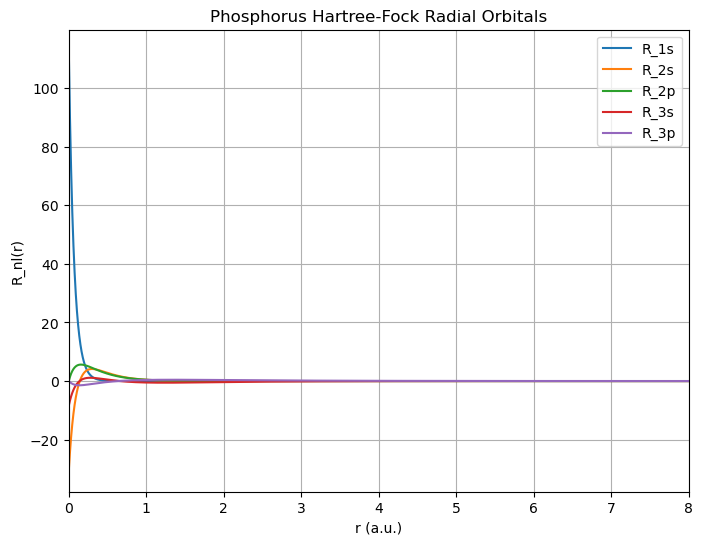

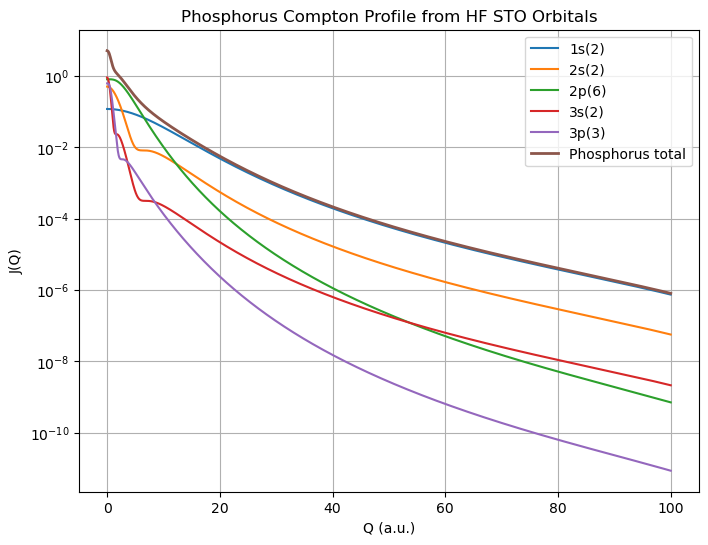

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Phosphorus Hartree-Fock STO data
# P: 1s(2) 2s(2) 2p(6) 3s(2) 3p(3)
# Format: (n_j, Z_j, C_j)
# =====================================================

phosphorus_1s = [
    (1,20.8264,  0.378728),
    (1,12.6329,  0.454633),
    (2,18.1768,  0.198318),
    (2, 6.9865,  0.001102),
    (2, 5.1340,  0.001500),
    (2, 3.7311, -0.000594),
    (3,39.5397, -0.000464),
    (3, 2.9558, -0.000130),
    (3, 1.9407, -0.000057),
    (3, 1.3616,  0.000011),
]

phosphorus_2s = [
    (1,20.8264,  0.067068),
    (1,12.6329, -0.483053),
    (2,18.1768,  0.055573),
    (2, 6.9865,  0.172637),
    (2, 5.1340,  0.826915),
    (2, 3.7311,  0.114274),
    (3,39.5397,  0.000249),
    (3, 2.9558, -0.003280),
    (3, 1.9407,  0.001381),
    (3, 1.3616, -0.000023),
]

phosphorus_3s = [
    (1,20.8264,  0.026409),
    (1,12.6329, -0.149611),
    (2,18.1768,  0.021237),
    (2, 6.9865,  0.065512),
    (2, 5.1340,  0.119933),
    (2, 3.7311,  0.273929),
    (3,39.5397,  0.000057),
    (3, 2.9558, -0.321673),
    (3, 1.9407, -0.583392),
    (3, 1.3616, -0.293770),
]

phosphorus_2p = [
    (2,20.2974,  0.000934),
    (2, 9.3161,  0.158097),
    (2, 5.5199,  0.499724),
    (2, 3.9517,  0.389661),
    (3,15.5633, -0.004175),
    (3, 2.2826,  0.003823),
    (3, 1.4968, -0.000307),
    (3, 1.0527,  0.000144),
]

phosphorus_3p = [
    (2,20.2974, -0.000893),
    (2, 9.3161, -0.048486),
    (2, 5.5199, -0.088168),
    (2, 3.9517, -0.136009),
    (3,15.5633, -0.004247),
    (3, 2.2826,  0.325638),
    (3, 1.4968,  0.522331),
    (3, 1.0527,  0.255540),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, phosphorus_1s)
R2s = R_nl(r, phosphorus_2s)
R3s = R_nl(r, phosphorus_3s)
R2p = R_nl(r, phosphorus_2p)
R3p = R_nl(r, phosphorus_3p)

print_R_formula(phosphorus_1s, "Si_R1s")
print_R_formula(phosphorus_2s, "Si_R2s")
print_R_formula(phosphorus_3s, "Si_R3s")
print_R_formula(phosphorus_2p, "Si_R2p")
print_R_formula(phosphorus_3p, "Si_R3p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)

# Aluminium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(3)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 3*J_3p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(3)": 3*J_3p,
    "J_total_phosphorus": J_total
})
print(table)
table.to_csv("Phosphorus_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Phosphorus Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_3p, label="3p(3)")
plt.plot(Q, J_total, label="Phosphorus total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Phosphorus Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()